In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import random

from faker import Faker

In [2]:
fake = Faker()

sku_categories = [
    "Dairy",
    "Frozen",
    "Snacks",
    "Beverages",
    "Household",
    "Fruits",
    "Vegetables"
]

zones = [
    "North",
    "South",
    "East",
    "West"
]

data = []

for i in range(5000):

    category = random.choice(sku_categories)

    basket_size = random.randint(1, 15)

    pick_time = random.randint(5, 40)

    congestion = random.randint(1, 10)

    warehouse_wait = random.randint(1, 20)

    rider_distance = round(
        random.uniform(1, 12),
        2
    )

    delivery_time = (
        pick_time
        +
        warehouse_wait
        +
        int(rider_distance * 2)
        +
        congestion
    )

    sla_breach = 1 if delivery_time > 30 else 0

    order_cost = round(
        pick_time * 1.5
        +
        warehouse_wait * 1.2
        +
        rider_distance * 8,
        2
    )

    row = {

        "order_id": i,

        "sku_category": category,

        "basket_size": basket_size,

        "pick_time": pick_time,

        "congestion_score": congestion,

        "warehouse_wait_time": warehouse_wait,

        "rider_distance_km": rider_distance,

        "delivery_time": delivery_time,

        "sla_breach": sla_breach,

        "order_cost": order_cost,

        "city_zone": random.choice(zones),

        "peak_hour": random.choice([0,1])
    }

    data.append(row)

df = pd.DataFrame(data)

df.head()

,order_id,sku_category,basket_size,pick_time,congestion_score,warehouse_wait_time,rider_distance_km,delivery_time,sla_breach,order_cost,city_zone,peak_hour
0,0,Snacks,2,25,10,1,7.07,50,1,95.26,West,0
1,1,Fruits,14,30,10,8,2.45,52,1,74.20,East,0
2,2,Beverages,5,27,6,4,1.30,39,1,55.70,South,0
3,3,Frozen,14,40,1,9,11.72,73,1,164.56,East,1
4,4,Household,14,15,1,7,9.48,41,1,106.74,East,1


In [4]:
df.to_csv(
    "data/operaiq_dataset.csv",
    index=False
)

# Business Problem

Quick commerce operations suffer from interconnected inefficiencies across warehouse picking, dispatch staging, and last-mile delivery. Most organizations optimize these independently, leading to localized improvements but poor system-wide efficiency.

OperaIQ aims to build an integrated operational intelligence system that models the complete order fulfillment lifecycle and identifies the true operational cost drivers affecting SLA adherence and unit economics.

In [5]:
total_orders = len(df)

avg_delivery_time = round(
    df["delivery_time"].mean(),
    2
)

sla_breach_rate = round(
    df["sla_breach"].mean() * 100,
    2
)

avg_order_cost = round(
    df["order_cost"].mean(),
    2
)

print("Total Orders:", total_orders)

print("Average Delivery Time:", avg_delivery_time)

print("SLA Breach Rate:", sla_breach_rate,"%")

print("Average Order Cost:", avg_order_cost)

Total Orders: 5000
Average Delivery Time: 50.72
SLA Breach Rate: 92.94 %
Average Order Cost: 97.61


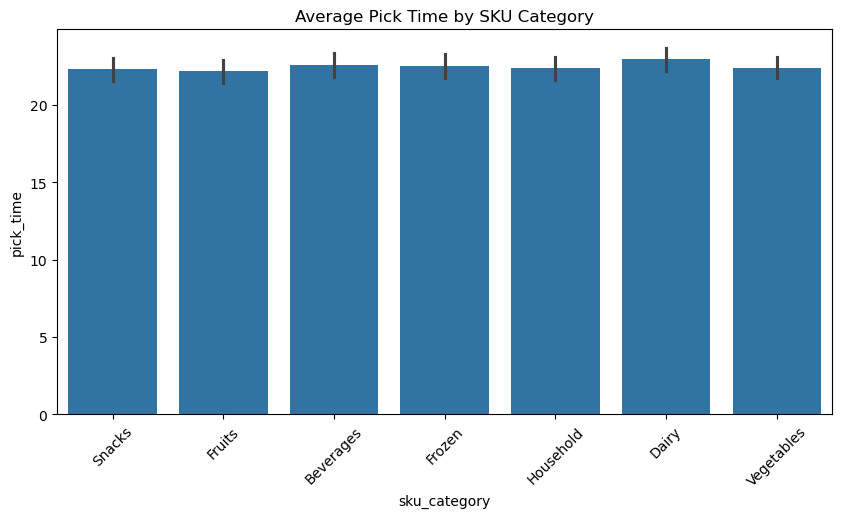

In [6]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="sku_category",
    y="pick_time",
    data=df
)

plt.title("Average Pick Time by SKU Category")

plt.xticks(rotation=45)

plt.show()

C:\Users\zaman asif\AppData\Local\Temp\ipykernel_12104\56715859.py:1: FutureWarning: The provided callable <function mean at 0x000001C7FFB64040> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot = pd.pivot_table(


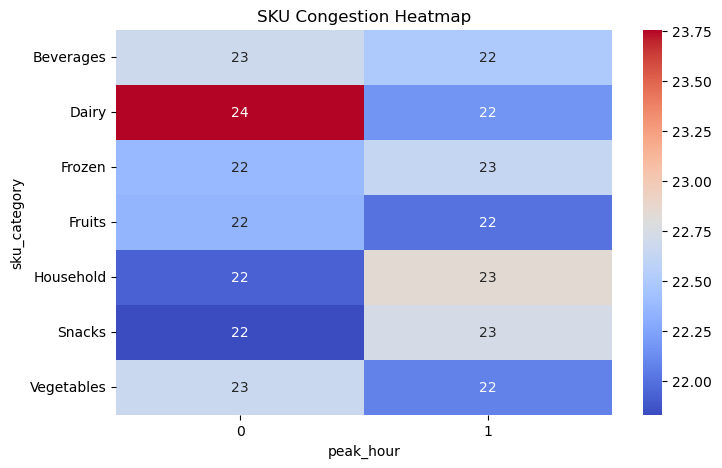

In [7]:
pivot = pd.pivot_table(
    df,
    values="pick_time",
    index="sku_category",
    columns="peak_hour",
    aggfunc=np.mean
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="coolwarm"
)

plt.title("SKU Congestion Heatmap")

plt.show()

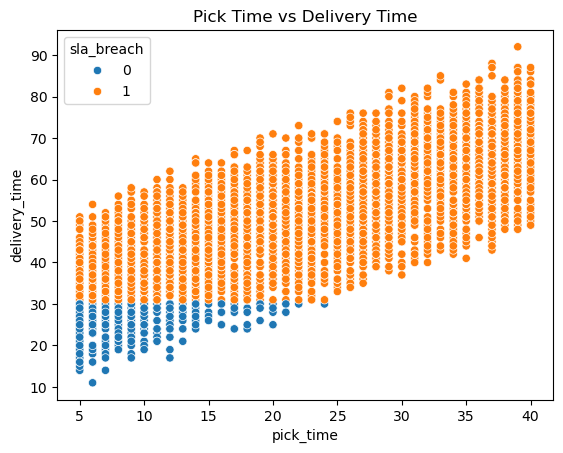

In [8]:
sns.scatterplot(
    x="pick_time",
    y="delivery_time",
    hue="sla_breach",
    data=df
)

plt.title(
    "Pick Time vs Delivery Time"
)

plt.show()

In [9]:
df["pick_cost"] = (
    df["pick_time"] * 1.5
)

df["staging_cost"] = (
    df["warehouse_wait_time"] * 1.2
)

df["last_mile_cost"] = (
    df["rider_distance_km"] * 8
)

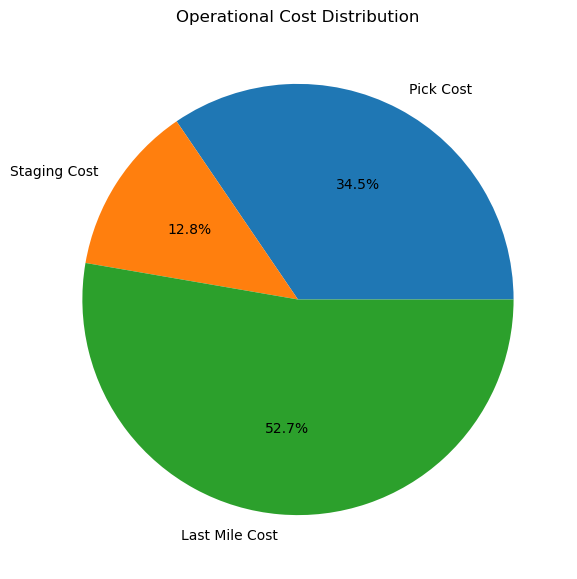

In [10]:
costs = [

    df["pick_cost"].mean(),

    df["staging_cost"].mean(),

    df["last_mile_cost"].mean()

]

labels = [

    "Pick Cost",

    "Staging Cost",

    "Last Mile Cost"
]

plt.figure(figsize=(7,7))

plt.pie(
    costs,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title("Operational Cost Distribution")

plt.show()

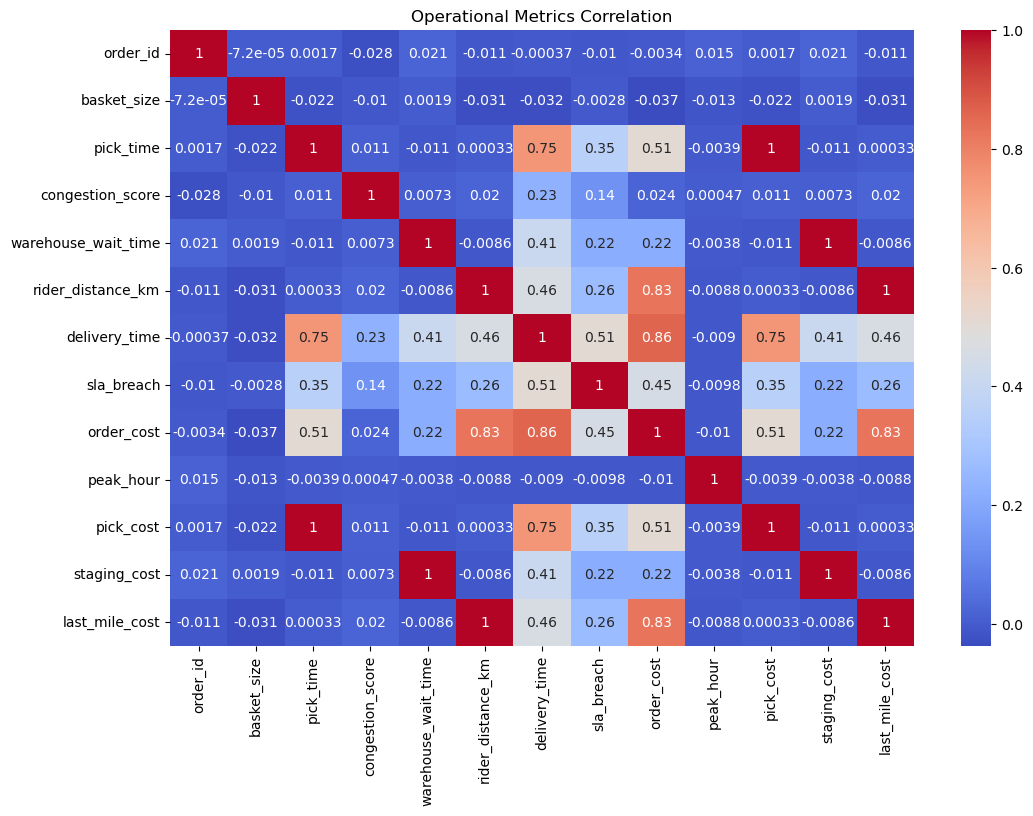

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Operational Metrics Correlation")

plt.show()

In [13]:
df["pick_cost"] = (
    df["pick_time"] * 1.5
)

df["staging_cost"] = (
    df["warehouse_wait_time"] * 1.2
)

df["last_mile_cost"] = (
    df["rider_distance_km"] * 8
)

In [14]:
df.to_csv(
    "data/operaiq_dataset.csv",
    index=False
)

# Key Insights

1. Warehouse pick latency strongly impacts downstream delivery SLA adherence.

2. Congestion during peak operational hours significantly increases fulfillment inefficiency.

3. Last-mile cost spikes are often caused by dispatch staging delays rather than rider inefficiency alone.

4. SKU category and basket complexity directly affect warehouse throughput.

5. Integrated operational optimization yields better unit economics than isolated subsystem optimization.

# Recommendations

1. Implement dynamic SKU slotting for fast-moving inventory.

2. Introduce predictive batching windows during peak operational hours.

3. Optimize warehouse staging workflows to reduce dispatch bottlenecks.

4. Use congestion-aware fulfillment routing for warehouse pickers.

5. Develop real-time operational monitoring dashboards for SLA risk detection.